# **K-means Clustering: Simple Applications**

#1. Phân nhóm chữ số viết tay

**Bộ cơ sở dữ liệu MNIST**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
Path to dataset files: /kaggle/input/mnist-dataset


Do k-means clustering làm việc với 1 điểm dữ liệu ảnh nên ta phải vectorization để có thể có 1 vector hàng.

In [2]:
import numpy as np
!pip install python-mnist
from mnist import MNIST # require `pip install python-mnist`
import matplotlib.pyplot as plt
import matplotlib
from sklearn.cluster import KMeans

In [3]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

In [4]:
def display_network(A, m = -1, n = -1): #show many images simultaneously
    opt_normalize = True
    opt_graycolor = True

    # Rescale
    A = A - np.average(A)

    # Compute rows & cols
    (row, col) = A.shape
    sz = int(np.ceil(np.sqrt(row)))
    buf = 1
    if m < 0 or n < 0:
        n = np.ceil(np.sqrt(col))
        m = np.ceil(col / n)


    image = np.ones(shape=(buf + m * (sz + buf), buf + n * (sz + buf)))

    if not opt_graycolor:
        image *= 0.1

    k = 0

    for i in range(int(m)):
        for j in range(int(n)):
            if k >= col:
                continue

            clim = np.max(np.abs(A[:, k]))

            if opt_normalize:
                image[buf + i * (sz + buf):buf + i * (sz + buf) + sz, buf + j * (sz + buf):buf + j * (sz + buf) + sz] = \
                    A[:, k].reshape(sz, sz) / clim
            else:
                image[buf + i * (sz + buf):buf + i * (sz + buf) + sz, buf + j * (sz + buf):buf + j * (sz + buf) + sz] = \
                    A[:, k].reshape(sz, sz) / np.max(np.abs(A))
            k += 1

    return image

def display_color_network(A):
    """
    # display receptive field(s) or basis vector(s) for image patches
    #
    # A         the basis, with patches as column vectors

    # In case the midpoint is not set at 0, we shift it dynamically

    :param A:
    :param file:
    :return:
    """
    if np.min(A) >= 0:
        A = A - np.mean(A)

    cols = np.round(np.sqrt(A.shape[1]))

    channel_size = A.shape[0] / 3
    dim = np.sqrt(channel_size)
    dimp = dim + 1
    rows = np.ceil(A.shape[1] / cols)

    B = A[0:channel_size, :]
    C = A[channel_size:2 * channel_size, :]
    D = A[2 * channel_size:3 * channel_size, :]

    B = B / np.max(np.abs(B))
    C = C / np.max(np.abs(C))
    D = D / np.max(np.abs(D))

    # Initialization of the image
    image = np.ones(shape=(dim * rows + rows - 1, dim * cols + cols - 1, 3))

    for i in range(int(rows)):
        for j in range(int(cols)):
            # This sets the patch
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 0] = B[:, i * cols + j].reshape(dim, dim)
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 1] = C[:, i * cols + j].reshape(dim, dim)
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 2] = D[:, i * cols + j].reshape(dim, dim)

    image = (image + 1) / 2

    #PIL.Image.fromarray(np.uint8(image * 255), 'RGB').save(filename)

    return image

In [5]:
import os
import shutil

src = "/kaggle/input/mnist-dataset"
dst = "/kaggle/working/mnist"

os.makedirs(dst, exist_ok=True)

shutil.copy(
    src + "/t10k-images.idx3-ubyte",
    dst + "/t10k-images-idx3-ubyte"
)

shutil.copy(
    src + "/t10k-labels.idx1-ubyte",
    dst + "/t10k-labels-idx1-ubyte"
)

shutil.copy(
    src + "/train-images.idx3-ubyte",
    dst + "/train-images-idx3-ubyte"
)

shutil.copy(
    src + "/train-labels.idx1-ubyte",
    dst + "/train-labels-idx1-ubyte"
)

print("Xong")

Xong


In [6]:
mndata = MNIST("/kaggle/working/mnist")
mndata.load_testing()
X = mndata.test_images
X0 = np.asarray(X)[:1000,:]/256.0
X = X0

K = 10
kmeans = KMeans(n_clusters=K).fit(X)

pred_label = kmeans.predict(X)

<class 'numpy.ndarray'>
(784, 10)


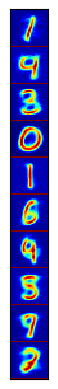

In [7]:
print(type(kmeans.cluster_centers_.T))
print(kmeans.cluster_centers_.T.shape)
A = display_network(kmeans.cluster_centers_.T, K, 1)

f1 = plt.imshow(A, interpolation='nearest', cmap = "jet")
f1.axes.get_xaxis().set_visible(False)
f1.axes.get_yaxis().set_visible(False)
plt.show()

# a colormap and a normalization instance
cmap = plt.cm.jet
norm = plt.Normalize(vmin=A.min(), vmax=A.max())

# map the normalized data to colors
# image is now RGBA (512x512x4)
image = cmap(norm(A))

In [8]:
N0 = 20;
X1 = np.zeros((N0*K, 784)) #(200, 784)
X2 = np.zeros((N0*K, 784))

for k in range(K):
    Xk = X0[pred_label == k, :]

    center_k = [kmeans.cluster_centers_[k]]
    neigh = NearestNeighbors(n_neighbors=N0).fit(Xk)
    dist, nearest_id  = neigh.kneighbors(center_k, N0)

    X1[N0*k: N0*k + N0,:] = Xk[nearest_id, :]
    X2[N0*k: N0*k + N0,:] = Xk[:N0, :]

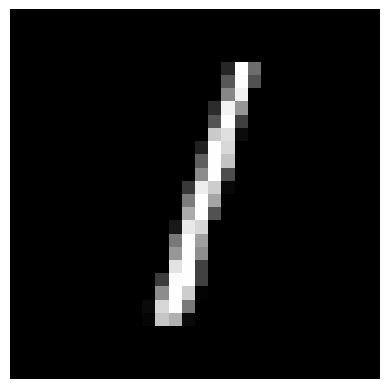

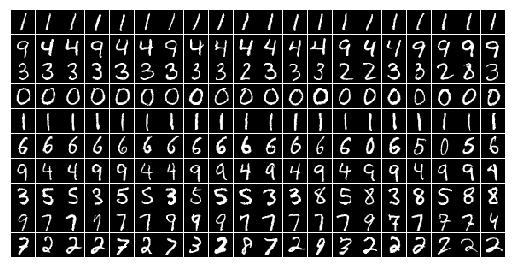

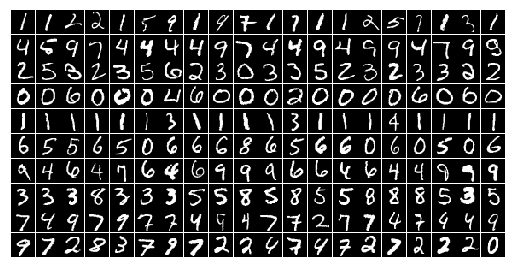

In [15]:
plt.axis('off')
A = display_network(X2.T, K, N0)
B = display_network(X1.T, K, N0)

imm = X1[0].reshape(28,28)
plt.show(plt.imshow(imm, cmap='gray'))

plt.axis('off')
f1 = plt.imshow(B, interpolation='nearest')
plt.gray()
plt.show()

plt.axis('off')
f2 = plt.imshow(A, interpolation='nearest' )
plt.gray()
plt.show()



*   Có 2 cluster là một thẳng, một chéo. K-means clustering nghĩ rằng đó là 2 chữ số khác nhau, dễ hiểu vì đây là một Unsupervised learning. Nếu có sự can thiệp của con người, ta có thể gộp 2 cluster vào làm một.
*   (4,9) được phân vào cùng một cluster, (7,8,9) cũng vậy. Với các cluster này, ta có thể tiếp tục áp dụng K-means clustering để phân nhỏ cluster hơn nữa.
* Trong clustering, có 1 kỹ thuật thường được sử dụng là Hierarchical clustering (clustering phân tầng). Có 2 loại hierarchical cluster:


  1.   Agglomerative (đi từ dưới lên): Ban đầu coi mỗi điểm dữ liệu là 1 cluster riêng, sau đó các cluster gần giống nhau sẽ được gộp vào thành một cluster, cứ lặp lại quá trình đến khi nhận được kết quả chấp nhận được.
  2.   Divisive (đi từ trên xuống): Ban đầu coi tất cả là 1 cluster, sau đó chia mỗi cluster bằng một thuật toán clustering nào đó.





# Object Segmentation

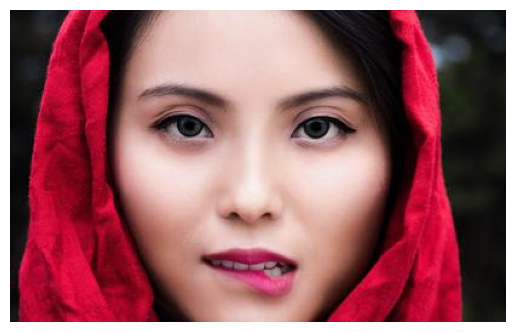

(258, 410, 3)


In [21]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

img = mpimg.imread('girl3.jpg')
plt.imshow(img)
imgplot = plt.imshow(img)
plt.axis('off')
plt.show()
print(img.shape)

In [17]:
X = img.reshape((img.shape[0]*img.shape[1], img.shape[2]))

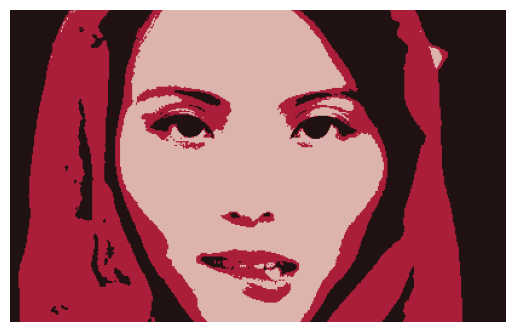

In [28]:
K = 3
kmeans = KMeans(n_clusters=K).fit(X)
label = kmeans.predict(X)

img1 = np.zeros_like(X)

for k in range(K):
  img1[label==k] = kmeans.cluster_centers_[k]

img1 = img1.reshape(img.shape[0], img.shape[1], img.shape[2])
plt.imshow(img1)
plt.axis('off')
plt.show()



# Image Compression

Mỗi pixel có thể nhận 256^3 = 16,777,216 triệu màu, tương đương 24 bit cho 1 điểm ảnh. Nếu muốn lưu mỗi điểm ảnh với số bit nhỏ hơn và chấp nhận mất dữ liệu ở một mức nào đó, ta có thể dùng k-means clustering.

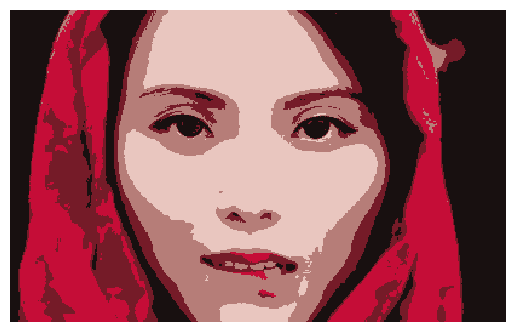

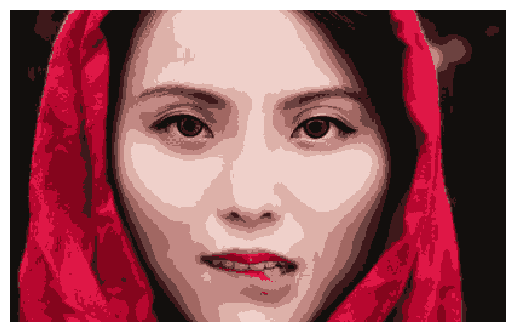

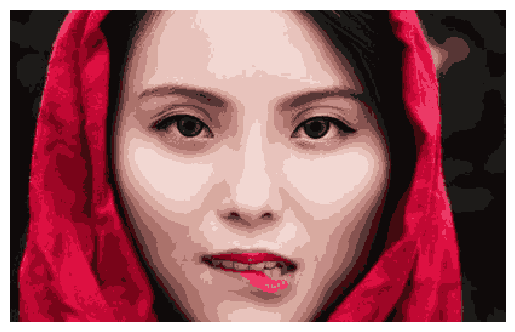

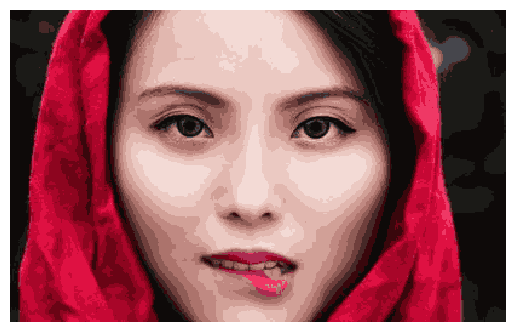

In [29]:
for K in [5, 10, 15, 20]:
    kmeans = KMeans(n_clusters=K).fit(X)
    label = kmeans.predict(X)

    img4 = np.zeros_like(X)
    # replace each pixel by its center
    for k in range(K):
        img4[label == k] = kmeans.cluster_centers_[k]
    # reshape and display output image
    img5 = img4.reshape((img.shape[0], img.shape[1], img.shape[2]))
    plt.imshow(img5, interpolation='nearest')
    plt.axis('off')
    plt.show()

  Khi số clusters tăng lên, chất lượng bức ảnh cũng tăng. Đồng thời, chúng ta chỉ cần lưu các centers và labels của mỗi điểm ảnh là đã có một bức ảnh nén (có mất dữ liệu)

**Cách thay 1 điểm dữ liệu bằng centers tương ứng là một trong số các kỹ thuật có tên chung là Vector Quantization (VQ). Không chỉ nén dữ liệu, VQ còn áp dụng rộng rãi trong các thuật toán tạo Vector Features cho bài toán phân loại (Classification)**